# Attention, Checked Against PyTorch

**Session 25 · no homework grades this · read it with the shapes in front of you**

Attention is four lines of linear algebra and one softmax. Everything that makes
it confusing is bookkeeping: which axis is the sequence, which is the head,
where the mask goes, and what `-inf` is doing there.

So this notebook writes it in NumPy where every intermediate is printable, tests
the properties that must hold, and then checks the result against PyTorch's
fused implementation. If your own version ever disagrees with
`scaled_dot_product_attention`, you have a bug and this is how you find it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

rng = np.random.default_rng(25)
np.set_printoptions(precision=3, suppress=True)
print("torch", torch.__version__)

torch 2.5.1


## 1. One head, in NumPy

Queries ask, keys advertise, values carry the content. The score of query *i*
against key *j* is their dot product, scaled by `sqrt(d_k)` so the softmax does
not saturate as the dimension grows.

In [2]:
def softmax(scores, axis=-1):
    shifted = scores - scores.max(axis=axis, keepdims=True)   # stability, as in Session 10
    exp = np.exp(shifted)
    return exp / exp.sum(axis=axis, keepdims=True)


def attend(queries, keys, values, mask=None):
    d_k = queries.shape[-1]
    scores = queries @ keys.swapaxes(-1, -2) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores)
    return weights @ values, weights


seq_len, d_k, d_v = 5, 8, 6
Q = rng.normal(size=(seq_len, d_k))
K = rng.normal(size=(seq_len, d_k))
V = rng.normal(size=(seq_len, d_v))

out, weights = attend(Q, K, V)
print("Q", Q.shape, " K", K.shape, " V", V.shape)
print("weights", weights.shape, " output", out.shape)

Q (5, 8)  K (5, 8)  V (5, 6)
weights (5, 5)  output (5, 6)


The shapes are the first check and they are not optional:

- `weights` is `(queries, keys)` — one row per query, one column per key;
- `output` is `(queries, d_v)` — the value dimension survives, the key dimension
  is summed away.

## 2. The properties that must hold

In [3]:
assert weights.shape == (seq_len, seq_len), "one weight per (query, key) pair"
assert out.shape == (seq_len, d_v), "output carries the value dimension"
assert np.allclose(weights.sum(axis=-1), 1.0), "every query's weights form a distribution"
assert (weights >= 0).all(), "softmax output is non-negative"

print("row sums:", weights.sum(axis=-1))
print("\nattention weights (rows = queries, columns = keys):")
print(weights)

row sums: [1. 1. 1. 1. 1.]

attention weights (rows = queries, columns = keys):
[[0.172 0.089 0.102 0.576 0.062]
 [0.081 0.578 0.046 0.035 0.26 ]
 [0.259 0.124 0.243 0.15  0.225]
 [0.235 0.042 0.064 0.538 0.121]
 [0.123 0.279 0.093 0.147 0.359]]


A weight matrix whose rows do not sum to one means the softmax ran along the
wrong axis — the single most common bug in a hand-written implementation, and
the reason the assertion above is worth keeping in your own code.

## 3. The causal mask

For a decoder, position *i* may not look at position *j > i*. The mask is
lower-triangular, and masked scores become `-inf` **before** the softmax so they
come out as exactly zero after it.

In [4]:
causal = np.tril(np.ones((seq_len, seq_len), dtype=bool))
print("mask (True = allowed):")
print(causal.astype(int))

masked_out, masked_weights = attend(Q, K, V, mask=causal)
print("\nweights under the causal mask:")
print(masked_weights)

assert np.allclose(np.triu(masked_weights, k=1), 0.0), "no query attends to the future"
assert np.allclose(masked_weights.sum(-1), 1.0), "rows still normalise"
print("\nfirst row attends to exactly", int((masked_weights[0] > 0).sum()), "position")
print("last row attends to exactly", int((masked_weights[-1] > 0).sum()), "positions")

mask (True = allowed):
[[1 0 0 0 0]
 [1 1 0 0 0]
 [1 1 1 0 0]
 [1 1 1 1 0]
 [1 1 1 1 1]]

weights under the causal mask:
[[1.    0.    0.    0.    0.   ]
 [0.123 0.877 0.    0.    0.   ]
 [0.414 0.198 0.388 0.    0.   ]
 [0.267 0.048 0.073 0.612 0.   ]
 [0.123 0.279 0.093 0.147 0.359]]

first row attends to exactly 1 position
last row attends to exactly 5 positions


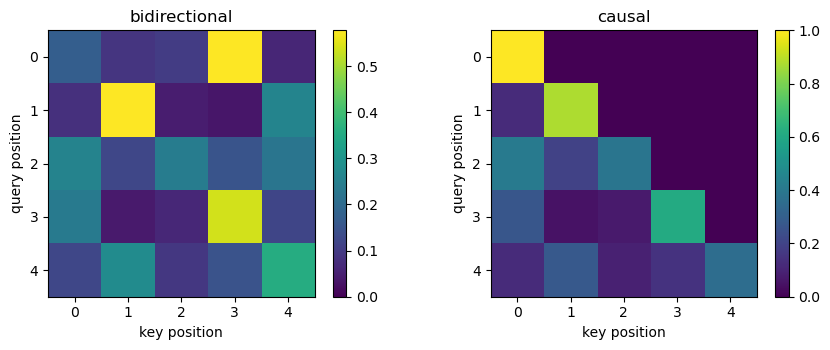

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, w, title in ((axes[0], weights, "bidirectional"),
                     (axes[1], masked_weights, "causal")):
    im = ax.imshow(w, cmap="viridis", vmin=0, vmax=w.max())
    ax.set_xlabel("key position"); ax.set_ylabel("query position")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 4. The same call, in PyTorch

`torch.nn.functional.scaled_dot_product_attention` is the fused kernel every
production model uses. It should agree with the NumPy version to floating-point
tolerance — and if it does not, the NumPy version is wrong.

In [6]:
Qt, Kt, Vt = (torch.tensor(a, dtype=torch.float64) for a in (Q, K, V))

torch_out = F.scaled_dot_product_attention(Qt, Kt, Vt)
print("unmasked  max |difference|:",
      float((torch_out - torch.tensor(out)).abs().max()))

torch_causal = F.scaled_dot_product_attention(Qt, Kt, Vt, is_causal=True)
print("causal    max |difference|:",
      float((torch_causal - torch.tensor(masked_out)).abs().max()))

assert torch.allclose(torch_out, torch.tensor(out))
assert torch.allclose(torch_causal, torch.tensor(masked_out))
print("\nboth agree")

unmasked  max |difference|: 5.551115123125783e-16
causal    max |difference|: 2.220446049250313e-16

both agree


## 5. Multi-head: split, attend, merge

One head learns one notion of relevance. *h* heads learn *h* of them, each in a
`d_model / h`-dimensional subspace, and their outputs are concatenated back to
`d_model`. The mechanics are entirely reshape and transpose — which is where the
bugs live.

In [7]:
d_model, n_heads = 24, 4
d_head = d_model // n_heads
seq = 6

x = rng.normal(size=(seq, d_model))
W_q, W_k, W_v = (rng.normal(size=(d_model, d_model)) * 0.1 for _ in range(3))
W_o = rng.normal(size=(d_model, d_model)) * 0.1

def split_heads(a):
    # (seq, d_model) -> (heads, seq, d_head)
    return a.reshape(seq, n_heads, d_head).transpose(1, 0, 2)

def merge_heads(a):
    # (heads, seq, d_head) -> (seq, d_model)
    return a.transpose(1, 0, 2).reshape(seq, d_model)

q, k, v = (split_heads(x @ W) for W in (W_q, W_k, W_v))
print("after split:", q.shape, "= (heads, seq, d_head)")

head_out, head_weights = attend(q, k, v)
print("per-head output:", head_out.shape, " per-head weights:", head_weights.shape)

merged = merge_heads(head_out)
attention_out = merged @ W_o
print("after merge:", merged.shape, " after output projection:", attention_out.shape)

assert np.allclose(merge_heads(split_heads(x)), x), "split then merge must be identity"
print("\nsplit/merge round-trips exactly")

after split: (4, 6, 6) = (heads, seq, d_head)
per-head output: (4, 6, 6)  per-head weights: (4, 6, 6)
after merge: (6, 24)  after output projection: (6, 24)

split/merge round-trips exactly


That last assertion is the one to steal. `reshape` and `transpose` in the wrong
order produce an array of the right *shape* and the wrong *contents*, and no
error is raised — the model simply trains badly. A round-trip check costs one
line and catches it immediately.

Each head learns a different pattern:

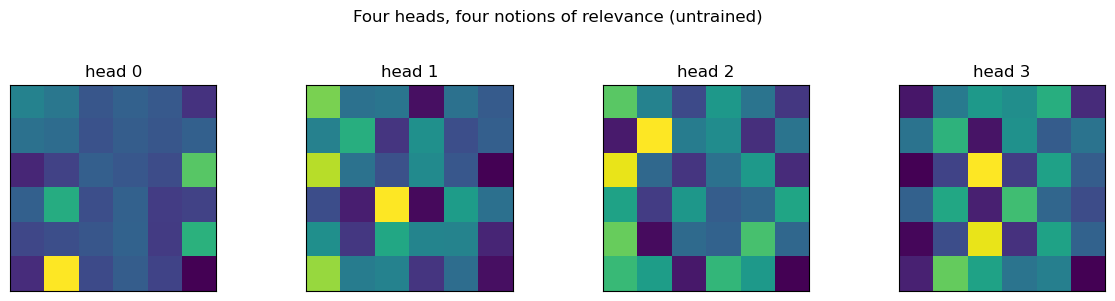

In [8]:
fig, axes = plt.subplots(1, n_heads, figsize=(12, 2.8))
for h, ax in enumerate(axes):
    ax.imshow(head_weights[h], cmap="viridis")
    ax.set_title(f"head {h}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Four heads, four notions of relevance (untrained)", y=1.06)
plt.tight_layout(); plt.show()

These are random projections, so the patterns mean nothing yet — the point is
that they *differ*, which is what averaging over one head would destroy.

## 6. A block, forward

Attention is one of five components. The block is: attention, residual, norm,
feed-forward, residual, norm — and it preserves the shape of its input, which is
why blocks stack.

In [9]:
import torch.nn as nn

class Block(nn.Module):
    def __init__(self, d_model=24, n_heads=4, d_ff=96, dropout=0.0):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, n_heads, dropout=dropout,
                                               batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))

    def forward(self, x, causal=False):
        mask = (torch.triu(torch.ones(x.size(1), x.size(1)), diagonal=1).bool()
                if causal else None)
        attended, weights = self.attention(x, x, x, attn_mask=mask, need_weights=True)
        x = self.norm1(x + attended)                 # residual, then norm
        x = self.norm2(x + self.feed_forward(x))     # residual, then norm
        return x, weights


torch.manual_seed(0)
block = Block().eval()
batch = torch.randn(2, seq, d_model)

with torch.no_grad():
    y, w = block(batch)
    y_causal, w_causal = block(batch, causal=True)

print("input ", tuple(batch.shape))
print("output", tuple(y.shape), " <- identical, which is why blocks stack")
print("attention weights", tuple(w.shape))
print("\ncausal weights, first sequence (upper triangle must be zero):")
print(w_causal[0].numpy().round(3))

input  (2, 6, 24)
output (2, 6, 24)  <- identical, which is why blocks stack
attention weights (2, 6, 6)

causal weights, first sequence (upper triangle must be zero):
[[1.    0.    0.    0.    0.    0.   ]
 [0.445 0.555 0.    0.    0.    0.   ]
 [0.339 0.225 0.437 0.    0.    0.   ]
 [0.245 0.279 0.214 0.262 0.    0.   ]
 [0.218 0.198 0.218 0.169 0.197 0.   ]
 [0.195 0.164 0.122 0.154 0.169 0.196]]


## 7. Why the scaling factor is there

Without dividing by `sqrt(d_k)`, dot products grow with the dimension, the
softmax saturates, and the gradient through it goes to zero. This is measurable
rather than folklore:

In [10]:
print(f"{'d_k':>5} {'max |score|':>13} {'largest weight':>16} {'entropy':>9}")
for d in (4, 16, 64, 256, 1024):
    q1 = rng.normal(size=(1, d))
    k1 = rng.normal(size=(20, d))
    for scaled in (True, False):
        s = q1 @ k1.T
        if scaled:
            s = s / np.sqrt(d)
        w1 = softmax(s)[0]
        entropy = float(-(w1 * np.log(w1 + 1e-12)).sum())
        tag = "scaled  " if scaled else "unscaled"
        print(f"{d:>5} {tag} {np.abs(s).max():>10.2f} {w1.max():>14.3f} {entropy:>9.3f}")

  d_k   max |score|   largest weight   entropy
    4 scaled         3.10          0.596     1.755
    4 unscaled       6.20          0.961     0.242
   16 scaled         2.08          0.191     2.644
   16 unscaled       8.31          0.771     0.900
   64 scaled         3.06          0.392     2.139
   64 unscaled      24.51          0.996     0.026
  256 scaled         1.90          0.143     2.739
  256 unscaled      30.36          0.969     0.159
 1024 scaled         1.45          0.148     2.667
 1024 unscaled      46.29          0.735     0.581


Unscaled, the largest weight approaches 1.0 and the entropy collapses: the
softmax has become an `argmax`, and an `argmax` has no useful gradient. Scaled,
the distribution stays soft as the dimension grows — which is the whole content
of that innocuous `/ sqrt(d_k)`.

## What to take from this

- Shapes first: weights are `(queries, keys)`, output is `(queries, d_v)`, and
  the rows of the weight matrix sum to one.
- The mask sets scores to `-inf` before the softmax, never after.
- Split/merge for heads must round-trip exactly. Assert it.
- Check your implementation against
  `F.scaled_dot_product_attention`; the fused version is the oracle.
- `/ sqrt(d_k)` keeps the softmax soft. Without it, attention saturates as the
  dimension grows.

## Where to go next

- **Reading, Session 25** — queries/keys/values, the block, and the three
  silhouettes (encoder, decoder, encoder-decoder).
- **Session 26** — the same blocks, pretrained, with a tokenizer in front.